# 08. 표 데이터와 MLP: 심장 질환 위험 예측

이번 노트북에서는 `heart.csv`를 사용해서 심장 질환 여부를 예측하는 MLP 모델을 만듭니다.

이 예제는 의학적 진단용이 아니라, 딥러닝 학습을 위한 교육용 위험 예측 실습입니다.

In [1]:
import numpy as np  # 숫자 배열 계산을 위한 라이브러리입니다.
import pandas as pd  # 표 데이터를 다루는 라이브러리입니다.
import matplotlib.pyplot as plt  # 학습 과정을 그래프로 보기 위한 라이브러리입니다.

from sklearn.model_selection import train_test_split  # 데이터를 학습/검증으로 나누는 도구입니다.
from sklearn.preprocessing import StandardScaler  # 숫자 범위를 표준화하는 도구입니다.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # 분류 평가 도구입니다.

from keras.models import Sequential  # 층을 순서대로 쌓는 모델입니다.
from keras.layers import Dense, Input  # Input은 입력 모양, Dense는 기본 신경망 층입니다.
from keras.callbacks import EarlyStopping  # 성능이 좋아지지 않으면 학습을 멈추는 콜백입니다.

DATA_PATH = r"C:\work\dataset\diabetes_or_cardiovascular\heart.csv" 

## 1. 데이터 불러오기와 간단 확인

In [2]:
df = pd.read_csv(DATA_PATH)

print("데이터 모양:", df.shape)
display(df.head())

데이터 모양: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 2. 입력 X와 정답 y 만들기

정답 컬럼은 `HeartDisease`입니다.

In [3]:
target_col = "HeartDisease"

X = df.drop(columns=[target_col])
y = df[target_col]

print("X 모양:", X.shape)
print("y 모양:", y.shape)
print("정답 분포:")
print(y.value_counts())

X 모양: (918, 11)
y 모양: (918,)
정답 분포:
HeartDisease
1    508
0    410
Name: count, dtype: int64


## 3. 문자 컬럼 원핫 인코딩

딥러닝 모델은 문자를 그대로 이해하지 못하므로 숫자 컬럼으로 바꿉니다.

In [4]:
categorical_cols = X.select_dtypes(exclude="number").columns.tolist()

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

print("문자 컬럼:", categorical_cols)
print("인코딩 후 X 모양:", X_encoded.shape)
display(X_encoded.head())

문자 컬럼: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
인코딩 후 X 모양: (918, 20)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,False,True,False,True,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,True,False,False,False,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,False,True,False,True,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,True,False,True,False,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,False,True,False,False,True,False,False,True,False,True,False,False,False,True


## 4. 학습/검증 데이터 나누기

검증 데이터는 모델이 학습 중 직접 보지 않은 데이터입니다.

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (734, 20)
X_val: (184, 20)
y_train: (734,)
y_val: (184,)


## 5. 스케일링

`StandardScaler`는 숫자 범위를 비슷하게 맞춰줍니다.

중요: `fit_transform`은 학습 데이터에만 사용하고, 검증 데이터에는 `transform`만 사용합니다.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("스케일링 후 X_train:", X_train_scaled.shape)
print("스케일링 후 X_val:", X_val_scaled.shape)

스케일링 후 X_train: (734, 20)
스케일링 후 X_val: (184, 20)


## 6. MLP 모델 만들기

이번 문제는 이진 분류입니다.

따라서 출력층은 `Dense(1, activation="sigmoid")`입니다.

In [7]:
input_dim = X_train_scaled.shape[1]  # 입력 특성 개수입니다.

model = Sequential([
    Input(shape=(input_dim,)),  # 입력 특성 개수를 모델에게 알려줍니다.
    Dense(16, activation="relu"),  # 첫 번째 은닉층입니다.
    Dense(8, activation="relu"),  # 두 번째 은닉층입니다.
    Dense(1, activation="sigmoid")  # 이진 분류 출력층입니다. 0~1 사이 확률을 출력합니다.
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

## 7. 컴파일하기

이진 분류이므로 손실 함수는 `binary_crossentropy`를 사용합니다.

In [8]:
model.compile(
    optimizer="adam",  # adam은 자주 쓰는 최적화 방법입니다.
    loss="binary_crossentropy",  # 이진 분류용 손실 함수입니다.
    metrics=["accuracy"]  # 학습 중 accuracy도 함께 확인합니다.
)

## 8. 학습하기

`EarlyStopping`은 검증 손실이 더 이상 좋아지지 않으면 학습을 멈춥니다.

In [14]:
early_stopping = EarlyStopping(
    monitor="val_loss",  # 검증 손실을 기준으로 봅니다.
    patience=10,  # 10번 동안 좋아지지 않으면 멈춥니다.
    restore_best_weights=True  # 가장 좋았던 시점의 가중치로 되돌립니다.
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)

print("실제로 학습한 epoch 수:", len(history.history["loss"]))

실제로 학습한 epoch 수: 43


## 9. 학습 곡선 보기

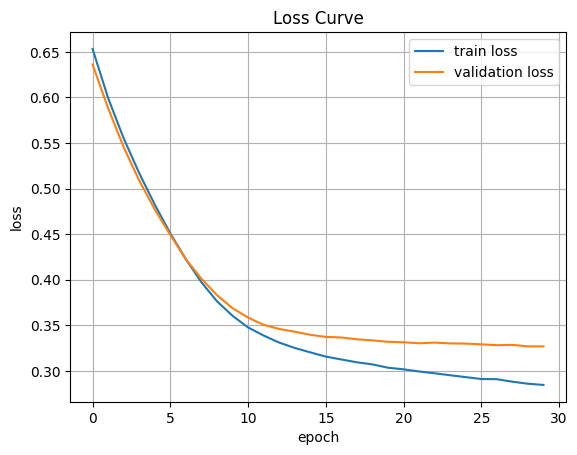

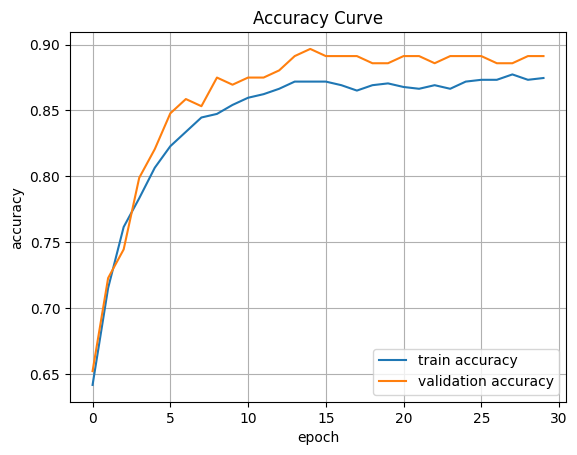

In [10]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("Loss Curve")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.title("Accuracy Curve")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 10. 검증 데이터 예측하기

sigmoid 출력은 0~1 사이 확률입니다.

0.5 이상이면 1, 0.5 미만이면 0으로 바꿔보겠습니다.

In [11]:
y_proba = model.predict(X_val_scaled, verbose=0).reshape(-1)
y_pred = (y_proba >= 0.5).astype(int)

print("예측 확률 앞 10개:", y_proba[:10])
print("예측 라벨 앞 10개:", y_pred[:10])

예측 확률 앞 10개: [0.9843408  0.3141208  0.93526244 0.5285022  0.22317438 0.44549865
 0.01995086 0.86791474 0.09042959 0.98617715]
예측 라벨 앞 10개: [1 0 1 1 0 0 0 1 0 1]


## 11. 평가하기

In [12]:
acc = accuracy_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)

print("Accuracy:", acc)
print("Confusion Matrix:")
print(cm)
print()
print("Classification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 0.8913043478260869
Confusion Matrix:
[[70 12]
 [ 8 94]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        82
           1       0.89      0.92      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



## 12. threshold 바꿔보기

기준값을 0.5에서 0.6으로 바꾸면 1이라고 예측하는 기준이 더 엄격해집니다.

In [13]:
threshold = 0.6
y_pred_06 = (y_proba >= threshold).astype(int)

print("threshold=0.6 Accuracy:", accuracy_score(y_val, y_pred_06))
print("threshold=0.6 Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_06))

threshold=0.6 Accuracy: 0.8967391304347826
threshold=0.6 Confusion Matrix:
[[73  9]
 [10 92]]


## 정리

이번 장에서는 표 데이터 이진 분류의 기본 흐름을 배웠습니다.

```text
EDA/전처리
MLP 모델 생성
binary_crossentropy로 학습
sigmoid 확률을 0/1 라벨로 변환
accuracy와 confusion matrix 확인
```